# QPAD Jitter Study Example

This notebook shows how to run start-to-end simulations using bmad/Impact-T for the linac and QPAD for the plasma interaction region. Each simulation introduces some jitters to the L0-L3 phase and gradients of the linac, so the results will vary from run-to-run. The run with QPAD enabled, you must call `initializeTao` with arguments `runQPAD = True` and a path to the simulation settings file `setQPADDefaultsFile = "qpad/2025-08-20-QPAD_defaults.yml"`. You can copy and modify the defaults file to run QPAD with your own custom settings. The notebook saves figures of each QPAD diagnostic dump using `saveAllQPADFigures()` and also displays interactive widgets for easy visualization using `plotInteractiveQPADFigure()`. See `UTILITY_QPAD.py` for detailed documentation of the QPAD visualization routines.

In [1]:
import FACET2_S2E as qs
import matplotlib.pyplot as plt
import numpy as np
import multiprocessing, subprocess
import os
import json

from IPython.display import display
from pathlib import Path
import os


In [2]:
filepath = str(Path(os.getcwd()).parent)

In [3]:
# This is a highly simplified jitter study; instead of considering various conditions, it just applies the standard jitter values to an unperturbed reference lattice


def jitterLinac(
    tao,
    
    L0BMatchStrings = None,
    L1MatchStrings  = None,
    L2MatchStrings  = None,
    L3MatchStrings  = None,
    
    L0BPhaseErrorDeg = 0.1,
    L1PhaseErrorDeg  = 0.7,
    L2PhaseErrorDeg  = 0.4,
    L3PhaseErrorDeg  = 0.4,

    L0BGradientErrorPercent = 0.5, 
    L1GradientErrorPercent  = 0.25,
    L2GradientErrorPercent  = 0.3,
    L3GradientErrorPercent  = 0.3,
):
    """Applies phase and amplitude errors to L0B, L1, L2, and L3
    
    Defaults values from https://docs.google.com/spreadsheets/d/1xeCUImz5uFSq6QA3wV91dG38s-8cyVXQMGw9hjPKa6M/edit?gid=0#gid=0
    """



    #Apply same errors to all elements in the linac region
    clipLimit = np.inf #Optionally limit maximum relative error
    
    #Convert to "turns"
    L0BPhaseError = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L0BPhaseErrorDeg / 360.0 
    L1PhaseError  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L1PhaseErrorDeg  / 360.0 
    L2PhaseError  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L2PhaseErrorDeg  / 360.0 
    L3PhaseError  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L3PhaseErrorDeg  / 360.0

    #Give as multiplier to base gradient
    L0BGradientErrorRelative = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L0BGradientErrorPercent / 100.0
    L1GradientErrorRelative  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L1GradientErrorPercent  / 100.0
    L2GradientErrorRelative  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L2GradientErrorPercent  / 100.0
    L3GradientErrorRelative  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L3GradientErrorPercent  / 100.0
    
    #Prevent recalculation until changes are made
    tao.cmd("set global lattice_calc_on = F")    
    

    [ tao.cmd(f"change ele {ele} PHI0 {L0BPhaseError}") for ele in L0BMatchStrings ]
    [ tao.cmd(f"change ele {ele} PHI0 {L1PhaseError}")  for ele in L1MatchStrings  ]
    [ tao.cmd(f"change ele {ele} PHI0 {L2PhaseError}")  for ele in L2MatchStrings  ]
    [ tao.cmd(f"change ele {ele} PHI0 {L3PhaseError}")  for ele in L3MatchStrings  ]
    
    for ele in L0BMatchStrings:
        baseGradient = tao.ele_gen_attribs(ele)["GRADIENT"]
        specificGradientError = L0BGradientErrorRelative * baseGradient
        tao.cmd(f"change ele {ele} GRADIENT {specificGradientError}")

    for ele in L1MatchStrings:
        baseGradient = tao.ele_gen_attribs(ele)["GRADIENT"]
        specificGradientError = L1GradientErrorRelative * baseGradient
        tao.cmd(f"change ele {ele} GRADIENT {specificGradientError}")
        
    for ele in L2MatchStrings:
        baseGradient = tao.ele_gen_attribs(ele)["GRADIENT"]
        specificGradientError = L2GradientErrorRelative * baseGradient
        tao.cmd(f"change ele {ele} GRADIENT {specificGradientError}")

    for ele in L3MatchStrings:
        baseGradient = tao.ele_gen_attribs(ele)["GRADIENT"]
        specificGradientError = L3GradientErrorRelative * baseGradient
        tao.cmd(f"change ele {ele} GRADIENT {specificGradientError}")
    
    #Reenable lattice calculations
    tao.cmd("set global lattice_calc_on = T")

    return {
    "L0BPhaseError" : L0BPhaseError,
    "L1PhaseError"  : L1PhaseError,
    "L2PhaseError"  : L2PhaseError,
    "L3PhaseError"  : L3PhaseError,

    "L0BGradientErrorRelative" : L0BGradientErrorRelative,
    "L1GradientErrorRelative"  : L1GradientErrorRelative,
    "L2GradientErrorRelative"  : L2GradientErrorRelative,
    "L3GradientErrorRelative"  : L3GradientErrorRelative
    }


    
def hashDict(d):
    return str(abs(hash(json.dumps(d, sort_keys=True))))



    
def worker(config):


    csrTF = True
    transverseWakes = False

    importedDefaultSettings = qs.loadConfig("setLattice_configs/2024-10-22_oneBunch_baseline3.yml",filepath)


    
    tao = qs.initializeTao(
        filePath = filepath,
        inputBeamFilePathSuffix = importedDefaultSettings["inputBeamFilePathSuffix"],
        csrTF = csrTF,
        numMacroParticles=5e4,
        scratchPath = filepath + "/tmp",
        randomizeFileNames = True,
        runQPAD= True,
        setQPADDefaultsFile = "/qpad/2025-08-20-QPAD_defaults.yml",
        transverseWakes = transverseWakes
    )




    
    # Set up lattice
    qs.setLattice(tao, **importedDefaultSettings)
    # print(importedDefaultSettings)

    L1MatchStrings, L2MatchStrings, L3MatchStrings, selectMarkers = qs.getLinacMatchStrings(tao)
    L0BMatchStrings = ["L0BF"]

    #Since we're jittering, we don't want Bmad to auto-compensate the magnets
    qs.disableAutoMagnetEnergyCompensation(tao)
    # print('LATTICE')
    # tao.cmd("show lat")

    
    #Jitter
    jitterDict = jitterLinac(
        tao,
            
        L0BMatchStrings = L0BMatchStrings,
        L1MatchStrings = L1MatchStrings,
        L2MatchStrings = L2MatchStrings,
        L3MatchStrings = L3MatchStrings,
    )

    hashStr = hashDict(jitterDict)
    # print(hashStr)
    print("tracking Beam")
    try:
        #Track

        # qs.trackBeam(tao, plasmaSIM=False, **importedDefaultSettings)
        # P3 = qs.getBeamAtElement(tao, "PENT")
        # P4 = qs.getBeamAtElement(tao, "PEXT")

        #Figure of LPS at PENT
        
        


        
        qs.trackBeam(tao, filepath, plasmaSIM=True, **importedDefaultSettings)
        P = qs.getBeamAtElement(tao, "PENT")
        

        #Figure of LPS at PENT
        
        P2 = qs.getBeamAtElement(tao, "PEXT")
        
        

        #Collect useful information like jitterDict into exportDict
        exportDict = config | {"csrTF":csrTF, "transverseWakes":transverseWakes} | jitterDict 
        exportDict = exportDict | qs.getBeamSpecs(P) 
        

        #Specify the output path
        exportPath = "../tmp/QPADjitterStudy/"
        qpadPath = exportPath+ "qpad_sim" + hashStr + "/"

        
        
        #Make the folder if it doesn't exist
        try:
            os.mkdir(exportPath)
        except:
            pass
        try:
            os.mkdir(qpadPath)
        except:
            pass
        
        fig = qs.plotMod(P, 'z', 'pz', bins=300, xlim = (-200e-6, 100e-6), ylim = (9.6e9, 10.2e9))
        fig.savefig(exportPath+hashStr+"_PENT.png")
        
        fig2 = qs.plotMod(P2, 'z', 'pz', bins=1000, xlim = (-200e-6, 100e-6), ylim = (2e9, 10.2e9))
        fig2.savefig(exportPath+hashStr+"_PEXT.png")

        
        # Export the ParticleGroup beam at PENT, PEXIT, a raw Bmad .lat file, the exportDict as JSON, and a PNG figure of the PENT LPS
        P.write(exportPath+hashStr+"_PENT.h5")
        P2.write(exportPath+hashStr+"_PEXT.h5")
        tao.cmd("write bmad "+exportPath+hashStr+"_lat.bmad")
        
        qs.saveAllQPADFigures(sim_fold = tao.qpadSimPath, 
                   quants = ['rho','ez', 'raw'],
                   plot_type = ['imshow','slice, r, 0e-6','z,pz'],
                   ylims = [[-100e-6,100e-6], [None,None], [None,None]],
                   xlims = [[None,None], [None,None], [None, None]],
                   vlims = [[0,2], [None,None], [None,None]],
                   cmaps = ['Blues', None, 'jet'],
                   figsize = (6,5),
                   save_fold = tao.qpadSimPath + '/figures')

        
        with open(exportPath+hashStr+"_jitterDict.json", "w") as f:
            json.dump(exportDict, f)

    except Exception as e:
        print("An error occurred:", e)

    return tao

    



## Run a start-to-end simulation with QPAD

This start-to-end simulation uses a single bunch configuration with 50,000 macroparticles and should take 5-10 minutes with QPAD running on 4 cores.

In [4]:
tao = worker({})

Environment set to:  /sdf/home/c/cropp/FACET2-S2E
-init /sdf/home/c/cropp/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
CSR on
Overwriting lattice with setLattice() defaults
No defaults file provided to setLattice(). Using /sdf/home/c/cropp/FACET2-S2E/setLattice_configs/defaults.yml
Number of macro particles = 50000.0
Beam created, written to /sdf/home/c/cropp/FACET2-S2E/tmp/beams/activeBeamFile_1809446267389494912.h5, and reinit to tao
tracking Beam
Running QPAD Simulation in /sdf/home/c/cropp/FACET2-S2E/tmp/beams/qpad_sim_1809446267389494912
 Terminating simulation...                                                          
Saving all QPAD Figures to /sdf/home/c/cropp/FACET2-S2E/tmp/beams/qpad_sim_1809446267389494912/figures


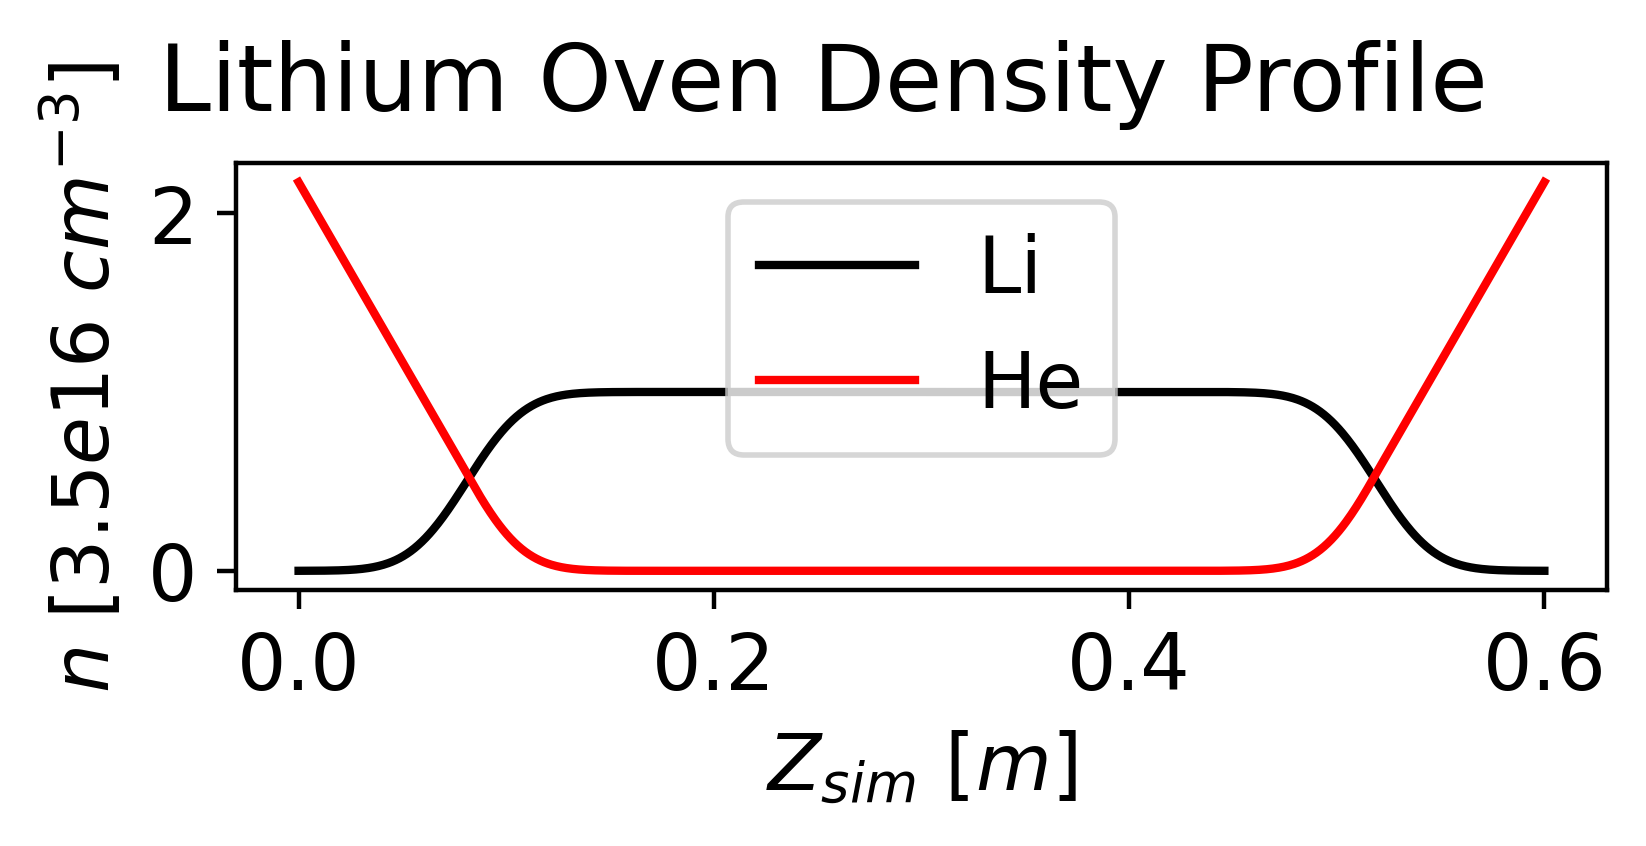

In [ ]:
# Plot the plasma density from the plasma config specified in tao.QPADDefaultsFile

fig = qs.plotPlasmaProfile(tao.QPADDefaultsFile, filepath, figsize = (4,2))
display(fig)

## Visualizing QPAD simulation Output

The `plotInteractiveQPADFigure()` routine takes as arguments a list of quantities to plot and plot_types for each quantity. There are currently options to plot 2D contours (imshow) or lineouts (slices) of field data (e.g. $\rho$, $E_z$, .. ). Arguments must be included to specify `xlims`, `ylims`, `vlims` for plot boundaries and colorbars (specify `None` to use default matplotlib values or when limits are not applicable). The `saveAllQPADFigures()` routine will iterate through all QPAD data dumps and save images directly to a specified output folder without displaying.

In [12]:
ui, update = qs.plotInteractiveQPADFigure(sim_fold = tao.qpadSimPath, 
                                       quants = ['rho','ez', 'raw'],
                                       plot_type = ['imshow','slice, r, 0e-6','z,pz'],
                                       ylims = [[-100e-6,100e-6], [None,None], [None,None]],
                                       xlims = [[None,None], [None,None], [None,None]],
                                       vlims = [[0,2], [None, None], [None,None]],
                                       cmaps = ['Blues', None, 'jet'],
                                       figsize = (5,5))
display(ui)
update()

In [13]:
ui, update = qs.plotInteractiveQPADFigure(sim_fold = tao.qpadSimPath, 
                                       quants = ['rho_plasma','rho_beam', 'rho_ion', 'rho_ion'],
                                       plot_type = ['imshow','imshow', 'imshow', 'slice,z,5e-6'],
                                       ylims = [[-100e-6,100e-6], [None,None], [None,None], [0,1]],
                                       xlims = [[None,None], [None,None], [None,None], [None,None]],
                                       vlims = [[0,2],[0,5],[0,1],[None, None]],
                                       cmaps = ['Blues','jet', 'jet', None],
                                       ncols = 2,
                                       figsize = (11,6))
display(ui)
update()

In [14]:
# update and save all QPAD figures (if needed)

qs.saveAllQPADFigures(sim_fold = tao.qpadSimPath, 
                   quants = ['rho','ez', 'raw'],
                   plot_type = ['imshow','slice, r, 0e-6','z,pz'],
                   ylims = [[-100e-6,100e-6], [None,None], [None,None]],
                   xlims = [[None,None], [None,None], [None, None]],
                   vlims = [[0,2], [None,None], [None,None]],
                   cmaps = ['Blues', None, 'jet'],
                   figsize = (6,5),
                   save_fold = tao.qpadSimPath + '/figures')

Saving all QPAD Figures to /sdf/home/c/cropp/FACET2-S2E/tmp/beams/qpad_sim_1809446267389494912/figures
